# 07 -- Risk & Forecasting

## Research Question
Where is supply-chain risk concentrated across the network, and what does a properly validated forecast say about Malaysia's export trajectory to 2030?

## Data
Supply Chain Risk Index (`data/processed/supply_chain_risk_index.csv`, DERIVED from World Bank + UN Comtrade + Pink Sheet). Malaysia export forecast (`data/processed/malaysia_export_forecast_2026_2030.csv`, DERIVED from DOSM). Nickel Monte Carlo (`data/processed/nickel_monte_carlo_12m.csv`).

## Method
Risk index: four equal-weighted, min-max normalised pillars (import dependency, logistics fragility, trade-partner concentration, commodity exposure), sensitivity-tested. Forecast: four models (naive, naive+drift, ETS, ARIMA) compared on a genuine 5-year rolling backtest. Monte Carlo: 10,000-path historical bootstrap. Full methodology in `docs/METHODOLOGY.md`, `docs/FORECASTING.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
risk = pd.read_csv('../data/processed/supply_chain_risk_index.csv')
print("Highest supply-chain risk (top 10 of 59):")
print(risk[['rank','Country','Region','supply_chain_risk_score']].head(10).round(1).to_string(index=False))
print("\nLowest risk (bottom 5):")
print(risk[['rank','Country','Region','supply_chain_risk_score']].tail(5).round(1).to_string(index=False))

Highest supply-chain risk (top 10 of 59):
 rank              Country        Region  supply_chain_risk_score
    1                 Cuba Latin America                     72.7
    2             Mongolia     East Asia                     62.5
    3                 Iraq   Middle East                     55.2
    4 Hong Kong SAR, China     East Asia                     54.1
    5     Macao SAR, China     East Asia                     51.7
    6   Iran, Islamic Rep.   Middle East                     48.2
    7             Ethiopia        Africa                     47.1
    8           Azerbaijan   Middle East                     46.7
    9               Angola        Africa                     46.3
   10              Algeria        Africa                     45.1

Lowest risk (bottom 5):
 rank Country        Region  supply_chain_risk_score
   55  France        Europe                     20.2
   56   Japan     East Asia                     19.6
   57   China     East Asia                     

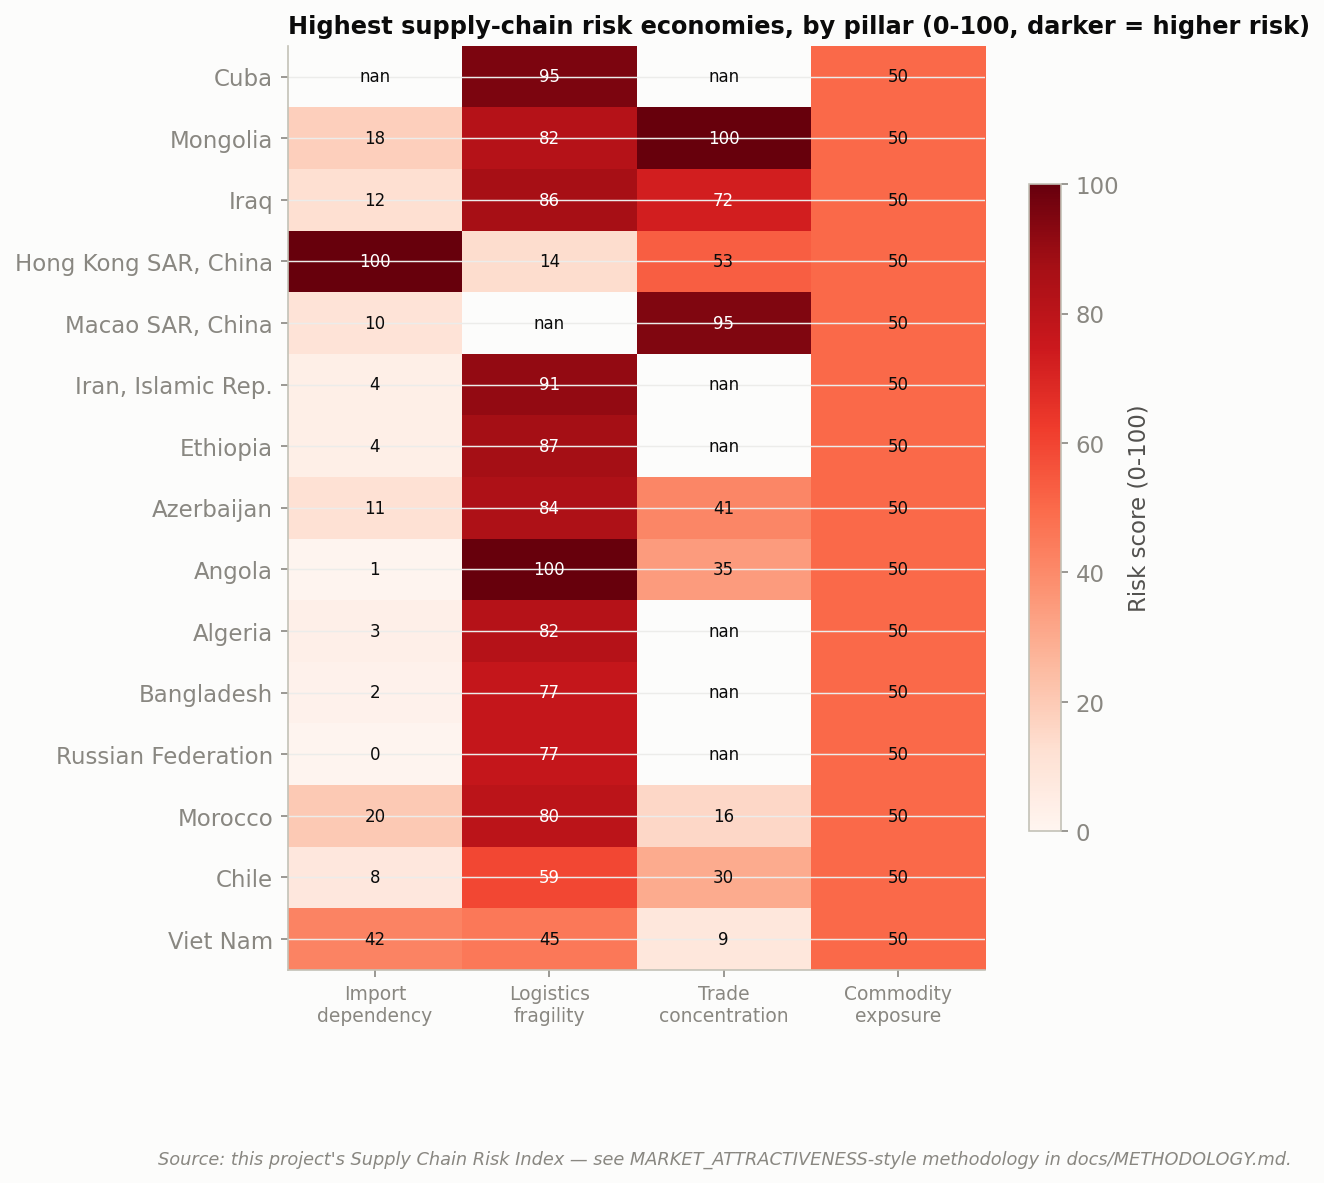

In [3]:
display(Image('../outputs/figures/10_risk_heatmap.png', width=650))

In [4]:
backtest = pd.read_csv('../data/processed/malaysia_export_forecast_backtest.csv')
print("Forecast model backtest (5-year rolling, 1-step-ahead RMSE):")
print(backtest.round(0).to_string(index=False))

Forecast model backtest (5-year rolling, 1-step-ahead RMSE):
      model          MAE         RMSE  MAPE_pct
naive_drift 1.312439e+11 1.626521e+11       9.0
      naive 1.532680e+11 1.783257e+11      10.0
      arima 1.736915e+11 1.929610e+11      12.0
   ets_holt 2.105725e+11 2.730402e+11      14.0


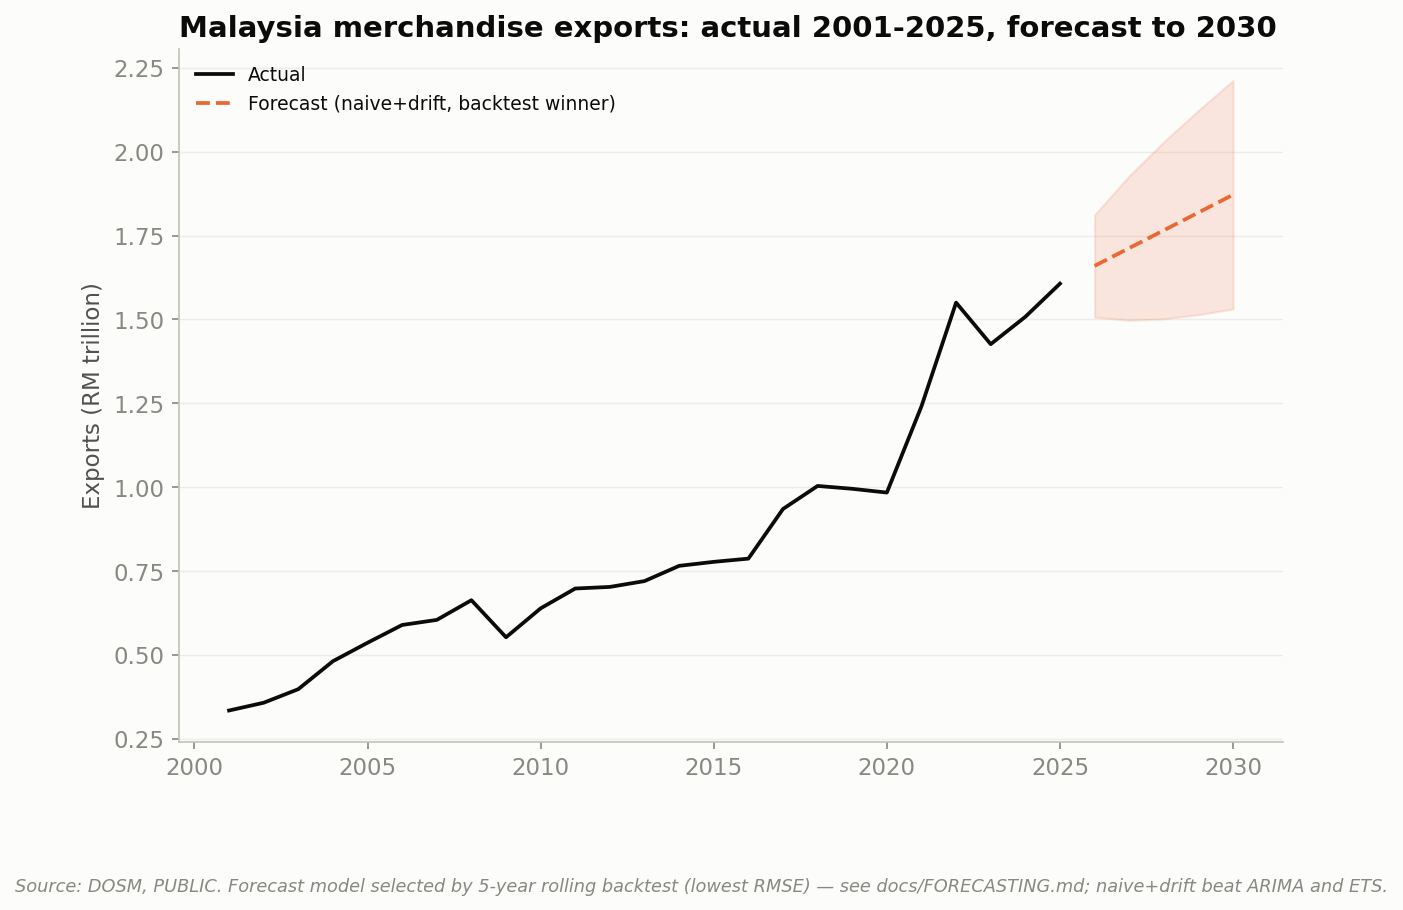

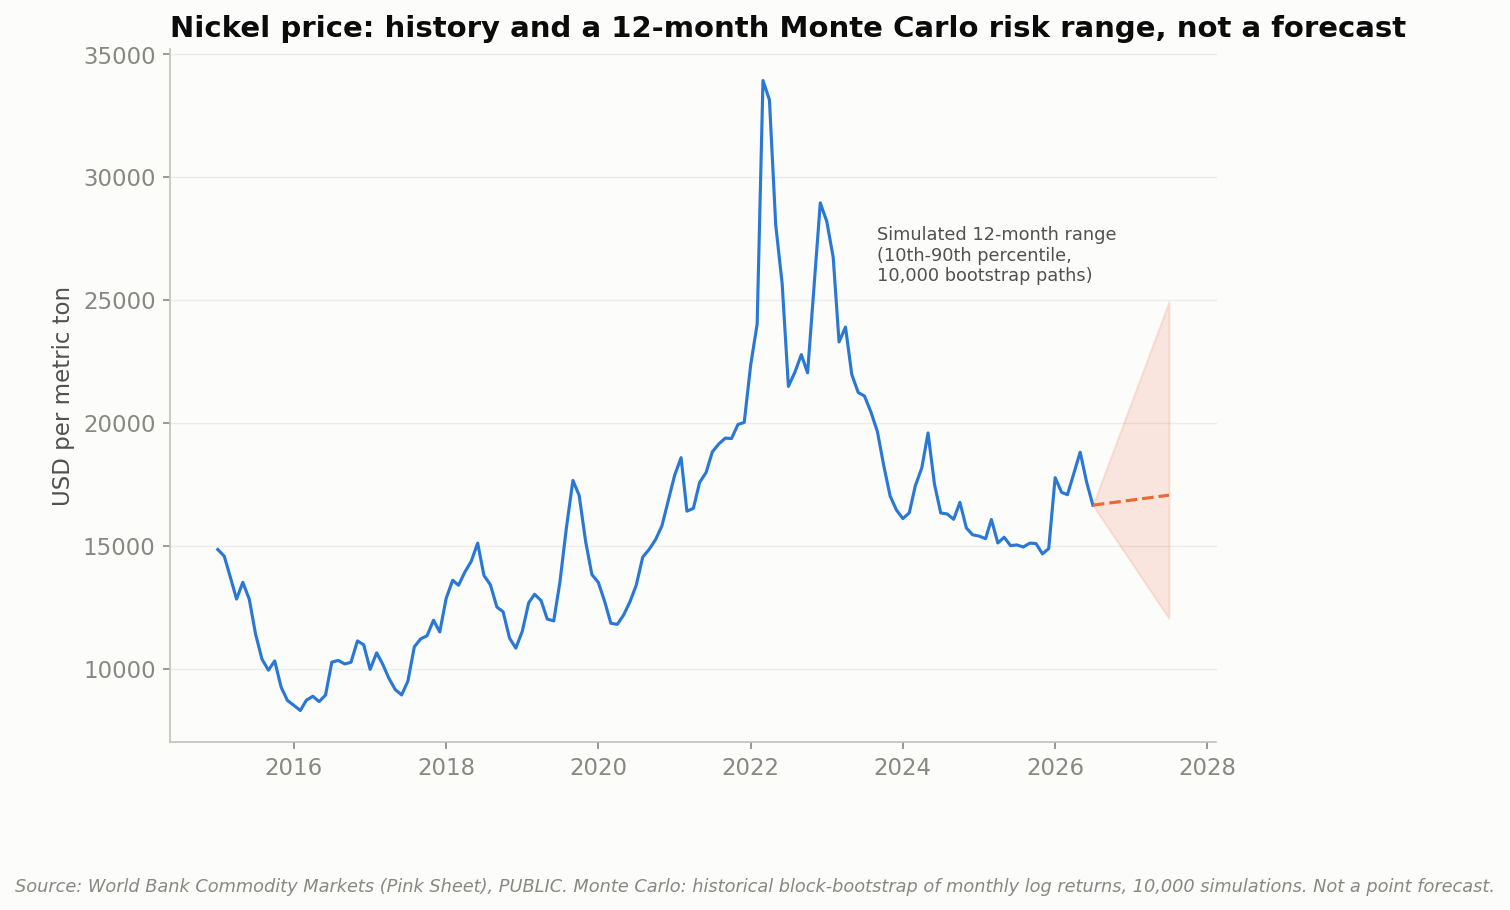

In [5]:
display(Image('../outputs/figures/13_malaysia_export_forecast.png', width=750))
display(Image('../outputs/figures/07_nickel_price_montecarlo.png', width=650))

## Finding

The highest-risk economies (Cuba, Mongolia, Iraq, Hong Kong, Macao) share small/concentrated/geopolitically-exposed profiles; the lowest (Germany, Canada, China, Japan, France) are large, diversified, logistically strong. Malaysia ranks 30th of 59 -- genuinely mid-pack.

The forecast backtest produced an honest, slightly unglamorous result: the simple naive-with-drift model beat both ARIMA and ETS on real out-of-sample accuracy. This is reported as the winning model rather than swapped for a more "impressive-looking" one, per this project's own research-integrity standard.

The nickel Monte Carlo gives a 25-27% probability of a >20% price increase over 12 months and a 13-17% probability of a >20% decrease, with two independent bootstrap methods agreeing closely -- real probabilities from real historical volatility, not invented numbers.

## Limitation

The risk index's commodity-exposure pillar is deliberately the crudest of the four (a single global-average figure, not country-specific) -- named explicitly, not disguised. See `docs/LIMITATIONS.md` item 6.

## Next Step

Notebook 08 brings all of this together specifically for Malaysia.